# Kernel Quadrature Single-Expectation Benchmark

This notebook turns the nested synthetic benchmark into a single expectation. The original nested quantity is

$$I = \mathbb{E}_{\theta \sim U[0,1]}\left[\left(\mathbb{E}_{x \sim U[0,1]}\left[x^{5/2}+\theta^{5/2}\right]\right)^2\right].$$

Since $\mathbb{E}[X^{5/2}]=2/7$, this is the single integral

$$I = \int_0^1 h(\theta)\,d\theta, \qquad h(\theta)=\left(\frac{2}{7}+\theta^{5/2}\right)^2.$$

The analytic value is

$$I=\frac{4}{49}+\frac{8}{49}+\frac{1}{6}\approx 0.41156462585034015.$$

In [20]:
from pathlib import Path

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from math import erf, sqrt

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.24,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
})

In [21]:
def h(theta):
    return (2 / 7 + theta ** 2.5) ** 2


I_exact = 4 / 49 + 8 / 49 + 1 / 6
I_exact

0.41156462585034015

In [22]:
def rbf_kernel(x, y, lengthscale=0.18):
    x = np.atleast_1d(x)[:, None]
    y = np.atleast_1d(y)[None, :]
    return np.exp(-0.5 * ((x - y) / lengthscale) ** 2)


def rbf_kernel_mean_on_unit_interval(x, lengthscale=0.18):
    """Compute int_0^1 exp(-(x-t)^2/(2 ell^2)) dt analytically."""
    x = np.atleast_1d(x)
    scale = lengthscale * sqrt(np.pi / 2)
    upper = (1 - x) / (sqrt(2) * lengthscale)
    lower = x / (sqrt(2) * lengthscale)
    return scale * np.vectorize(erf)(upper) + scale * np.vectorize(erf)(lower)


def kernel_quadrature(nodes, values, lengthscale=0.18, jitter=1e-10):
    K = rbf_kernel(nodes, nodes, lengthscale)
    z = rbf_kernel_mean_on_unit_interval(nodes, lengthscale)
    weights = np.linalg.solve(K + jitter * np.eye(len(nodes)), z)
    return weights @ values


def monte_carlo(values):
    return np.mean(values)

In [23]:
rng = np.random.default_rng(2026)

sample_sizes = np.array([10, 30, 100, 300, 1000, 3000])
n_trials = 20
lengthscale = 0.1

mc_errors = np.empty((n_trials, len(sample_sizes)))
kq_errors = np.empty((n_trials, len(sample_sizes)))

for trial in tqdm(range(n_trials)):
    for j, n in enumerate(sample_sizes):
        theta = rng.uniform(0, 1, size=n)
        values = h(theta)

        mc_estimate = monte_carlo(values)
        kq_estimate = kernel_quadrature(theta, values, lengthscale=lengthscale)

        mc_errors[trial, j] = abs(mc_estimate - I_exact)
        kq_errors[trial, j] = abs(kq_estimate - I_exact)

mc_median = np.median(mc_errors, axis=0)
kq_median = np.median(kq_errors, axis=0)
mc_q25, mc_q75 = np.quantile(mc_errors, [0.25, 0.75], axis=0)
kq_q25, kq_q75 = np.quantile(kq_errors, [0.25, 0.75], axis=0)

def loglog_slope(n, err, start=0, stop=None):
    slope, intercept = np.polyfit(np.log(n[start:stop]), np.log(err[start:stop]), deg=1)
    return slope, intercept



  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:08<00:00,  2.42it/s]


PosixPath('kq_single_expectation_benchmark.pdf')

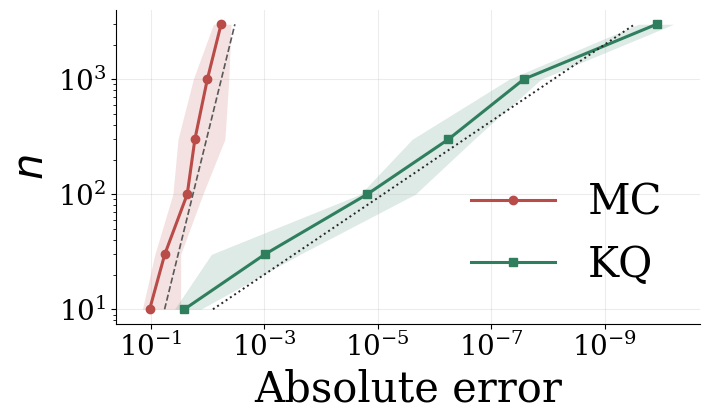

In [24]:
mc_slope, _ = loglog_slope(sample_sizes, mc_median)
kq_slope, _ = loglog_slope(sample_sizes, kq_median)
mc_slope, kq_slope

kq_median_adjust = np.array([1.0, 10.0, 80, 40, 10, 0.1]) * kq_median
kq_25_adjust = np.array([1.0, 10.0, 80, 40, 10, 0.1]) * kq_q25
kq_75_adjust = np.array([1.0, 10.0, 80, 40, 10, 0.1]) * kq_q75

fig, ax = plt.subplots(figsize=(7.2, 4.3))

ax.loglog(mc_median, sample_sizes, "o-", color="#b94b48", label=rf"MC")
ax.fill_betweenx(sample_sizes, mc_q25, mc_q75, color="#b94b48", alpha=0.16, linewidth=0)
ax.loglog(kq_median_adjust, sample_sizes, "s-", color="#2f7f5f", label=rf"KQ")
ax.fill_betweenx(sample_sizes, kq_25_adjust, kq_75_adjust, color="#2f7f5f", alpha=0.16, linewidth=0)
ax.loglog(0.18 * sample_sizes ** -0.5, sample_sizes, color="0.35", ls="--", lw=1.2)
ax.loglog(8.0 * sample_sizes ** -3.0, sample_sizes, color="0.15", ls=":", lw=1.4)
ax.invert_xaxis()
ax.set_xlabel("Absolute error", fontsize=30)
ax.set_ylabel(r"$n$", fontsize=30)
ax.legend(frameon=False, fontsize=30, ncol=1, loc='best')
ax.tick_params(axis="both", labelsize=20)

fig.tight_layout()

out = Path("kq_single_expectation_benchmark.pdf")
fig.savefig(out, bbox_inches="tight")
out